In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


Using device: cuda


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    # MNIST is already 0..1 after ToTensor()
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 513kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.74MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.6MB/s]


In [4]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()  # enables training behaviors like Dropout
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()       # reset gradients
        logits = model(x)           # forward pass (raw scores)
        loss = criterion(logits, y) # compute loss
        loss.backward()             # backprop gradients
        optimizer.step()            # update weights

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()  # disables Dropout, uses running stats for BatchNorm
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += x.size(0)

    return total_loss / total, correct / total


def run_training(model, optimizer, epochs):
    criterion = nn.CrossEntropyLoss()  # combines LogSoftmax + NLLLoss
    model = model.to(device)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        te_loss, te_acc = evaluate(model, test_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["test_loss"].append(te_loss)
        history["test_acc"].append(te_acc)

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "
              f"test_loss={te_loss:.4f} test_acc={te_acc:.4f}")

    return history


In [5]:
class CNNBase(nn.Module):
    def __init__(self, fc_units=128):
        super().__init__()
        # Conv layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)   # 28->26
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)  # 26->24
        self.pool  = nn.MaxPool2d(2, 2)                # 24->12
        self.drop  = nn.Dropout(0.25)

        # Fully-connected layers
        self.fc1 = nn.Linear(64 * 12 * 12, fc_units)
        self.fc2 = nn.Linear(fc_units, 10)

        # Activation
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.pool(x)
        x = self.drop(x)

        x = x.view(x.size(0), -1)     # flatten
        x = self.act(self.fc1(x))
        x = self.fc2(x)               # logits (NO softmax here)
        return x


In [6]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

cnn1 = CNNBase(fc_units=128)
opt_cnn1 = optim.Adam(cnn1.parameters(), lr=1e-3)

history_cnn1 = run_training(cnn1, opt_cnn1, epochs=10)

cnn1_final_test_acc = history_cnn1["test_acc"][-1]
print(f"\nCNN-1 FINAL TEST ACCURACY: {cnn1_final_test_acc*100:.2f}%")


Epoch 01/10 | train_loss=0.2004 train_acc=0.9404 | test_loss=0.0541 test_acc=0.9825
Epoch 02/10 | train_loss=0.0532 train_acc=0.9838 | test_loss=0.0476 test_acc=0.9856
Epoch 03/10 | train_loss=0.0357 train_acc=0.9890 | test_loss=0.0314 test_acc=0.9893
Epoch 04/10 | train_loss=0.0257 train_acc=0.9918 | test_loss=0.0349 test_acc=0.9882
Epoch 05/10 | train_loss=0.0206 train_acc=0.9931 | test_loss=0.0338 test_acc=0.9893
Epoch 06/10 | train_loss=0.0152 train_acc=0.9949 | test_loss=0.0354 test_acc=0.9895
Epoch 07/10 | train_loss=0.0112 train_acc=0.9964 | test_loss=0.0356 test_acc=0.9893
Epoch 08/10 | train_loss=0.0117 train_acc=0.9962 | test_loss=0.0377 test_acc=0.9899
Epoch 09/10 | train_loss=0.0084 train_acc=0.9971 | test_loss=0.0458 test_acc=0.9885
Epoch 10/10 | train_loss=0.0088 train_acc=0.9971 | test_loss=0.0402 test_acc=0.9900

CNN-1 FINAL TEST ACCURACY: 99.00%


In [7]:
class MLP512_256_128(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(784, 512)
        self.bn1 = nn.BatchNorm1d(512)

        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)

        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)

        self.out = nn.Linear(128, 10)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)          # (B,1,28,28) -> (B,784)

        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = self.act(x)

        x = self.out(x)              # logits
        return x


In [8]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

mlp1 = MLP512_256_128()

# SGD config (common + works well): lr=0.1 with momentum
opt_mlp1 = optim.SGD(mlp1.parameters(), lr=0.1, momentum=0.9)

history_mlp1 = run_training(mlp1, opt_mlp1, epochs=20)

mlp1_final_test_acc = history_mlp1["test_acc"][-1]
print(f"\nMLP-1 FINAL TEST ACCURACY: {mlp1_final_test_acc*100:.2f}%")


Epoch 01/20 | train_loss=0.1878 train_acc=0.9430 | test_loss=0.0961 test_acc=0.9693
Epoch 02/20 | train_loss=0.0761 train_acc=0.9764 | test_loss=0.0832 test_acc=0.9758
Epoch 03/20 | train_loss=0.0514 train_acc=0.9835 | test_loss=0.0827 test_acc=0.9744
Epoch 04/20 | train_loss=0.0385 train_acc=0.9875 | test_loss=0.0692 test_acc=0.9799
Epoch 05/20 | train_loss=0.0266 train_acc=0.9912 | test_loss=0.0641 test_acc=0.9830
Epoch 06/20 | train_loss=0.0216 train_acc=0.9929 | test_loss=0.0805 test_acc=0.9785
Epoch 07/20 | train_loss=0.0188 train_acc=0.9935 | test_loss=0.0666 test_acc=0.9819
Epoch 08/20 | train_loss=0.0135 train_acc=0.9958 | test_loss=0.0661 test_acc=0.9828
Epoch 09/20 | train_loss=0.0115 train_acc=0.9961 | test_loss=0.0675 test_acc=0.9839
Epoch 10/20 | train_loss=0.0101 train_acc=0.9963 | test_loss=0.0713 test_acc=0.9830
Epoch 11/20 | train_loss=0.0088 train_acc=0.9971 | test_loss=0.0724 test_acc=0.9823
Epoch 12/20 | train_loss=0.0082 train_acc=0.9975 | test_loss=0.0602 test_acc

In [9]:
class MLP256(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(784, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.act = nn.ReLU()

        self.out = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)      # (B,1,28,28) -> (B,784)

        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act(x)

        x = self.out(x)          # logits
        return x


In [10]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

mlp2 = MLP256()
opt_mlp2 = optim.Adam(mlp2.parameters(), lr=1e-3)

history_mlp2 = run_training(mlp2, opt_mlp2, epochs=15)

mlp2_final_test_acc = history_mlp2["test_acc"][-1]
print(f"\nMLP-2 FINAL TEST ACCURACY: {mlp2_final_test_acc*100:.2f}%")

print("\n========== FILL THIS IN YOUR TABLE ==========")
print(f"CNN-1  | FC=128         | Adam | 10  | {cnn1_final_test_acc*100:.2f}%")
print(f"MLP-1  | 512-256-128    | SGD  | 20  | {mlp1_final_test_acc*100:.2f}%")
print(f"MLP-2  | 256            | Adam | 15  | {mlp2_final_test_acc*100:.2f}%")


Epoch 01/15 | train_loss=0.2534 train_acc=0.9313 | test_loss=0.1348 test_acc=0.9619
Epoch 02/15 | train_loss=0.1078 train_acc=0.9694 | test_loss=0.0960 test_acc=0.9701
Epoch 03/15 | train_loss=0.0711 train_acc=0.9791 | test_loss=0.0812 test_acc=0.9758
Epoch 04/15 | train_loss=0.0526 train_acc=0.9852 | test_loss=0.0735 test_acc=0.9768
Epoch 05/15 | train_loss=0.0400 train_acc=0.9887 | test_loss=0.0757 test_acc=0.9768
Epoch 06/15 | train_loss=0.0305 train_acc=0.9920 | test_loss=0.0685 test_acc=0.9787
Epoch 07/15 | train_loss=0.0227 train_acc=0.9943 | test_loss=0.0773 test_acc=0.9763
Epoch 08/15 | train_loss=0.0199 train_acc=0.9947 | test_loss=0.0680 test_acc=0.9804
Epoch 09/15 | train_loss=0.0175 train_acc=0.9956 | test_loss=0.0745 test_acc=0.9772
Epoch 10/15 | train_loss=0.0148 train_acc=0.9961 | test_loss=0.0704 test_acc=0.9793
Epoch 11/15 | train_loss=0.0132 train_acc=0.9964 | test_loss=0.0750 test_acc=0.9791
Epoch 12/15 | train_loss=0.0100 train_acc=0.9978 | test_loss=0.0746 test_acc

In [11]:
class CNNWithActivation(nn.Module):
    def __init__(self, act_name="relu", fc_units=128):
        super().__init__()
        acts = {
            "sigmoid": nn.Sigmoid(),
            "tanh": nn.Tanh(),
            "relu": nn.ReLU()
        }
        if act_name not in acts:
            raise ValueError("act_name must be one of: sigmoid, tanh, relu")
        self.act = acts[act_name]

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.pool  = nn.MaxPool2d(2, 2)
        self.drop  = nn.Dropout(0.25)

        self.fc1 = nn.Linear(64 * 12 * 12, fc_units)
        self.fc2 = nn.Linear(fc_units, 10)

    def forward(self, x):
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.pool(x)
        x = self.drop(x)

        x = x.view(x.size(0), -1)
        x = self.act(self.fc1(x))
        x = self.fc2(x)  # logits
        return x


In [12]:
def run_activation_experiments_cnn(epochs=10, lr=1e-3):
    activations = ["sigmoid", "tanh", "relu"]
    act_histories = {}

    for act in activations:
        torch.manual_seed(42)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(42)

        model = CNNWithActivation(act_name=act, fc_units=128)
        optimizer = optim.Adam(model.parameters(), lr=lr)

        print("\n====================================")
        print(f"Training CNN with activation: {act.upper()}")
        print("====================================")
        hist = run_training(model, optimizer, epochs=epochs)

        act_histories[act] = hist

    return act_histories

cnn_act_histories = run_activation_experiments_cnn(epochs=10, lr=1e-3)



Training CNN with activation: SIGMOID
Epoch 01/10 | train_loss=0.8836 train_acc=0.7386 | test_loss=0.2711 test_acc=0.9269
Epoch 02/10 | train_loss=0.2287 train_acc=0.9370 | test_loss=0.1818 test_acc=0.9484
Epoch 03/10 | train_loss=0.1674 train_acc=0.9523 | test_loss=0.1478 test_acc=0.9566
Epoch 04/10 | train_loss=0.1314 train_acc=0.9622 | test_loss=0.1133 test_acc=0.9665
Epoch 05/10 | train_loss=0.1041 train_acc=0.9693 | test_loss=0.0934 test_acc=0.9733
Epoch 06/10 | train_loss=0.0821 train_acc=0.9761 | test_loss=0.0792 test_acc=0.9759
Epoch 07/10 | train_loss=0.0686 train_acc=0.9803 | test_loss=0.0745 test_acc=0.9775
Epoch 08/10 | train_loss=0.0584 train_acc=0.9834 | test_loss=0.0677 test_acc=0.9783
Epoch 09/10 | train_loss=0.0507 train_acc=0.9855 | test_loss=0.0600 test_acc=0.9802
Epoch 10/10 | train_loss=0.0435 train_acc=0.9872 | test_loss=0.0511 test_acc=0.9834

Training CNN with activation: TANH
Epoch 01/10 | train_loss=0.2248 train_acc=0.9362 | test_loss=0.0892 test_acc=0.9735
E

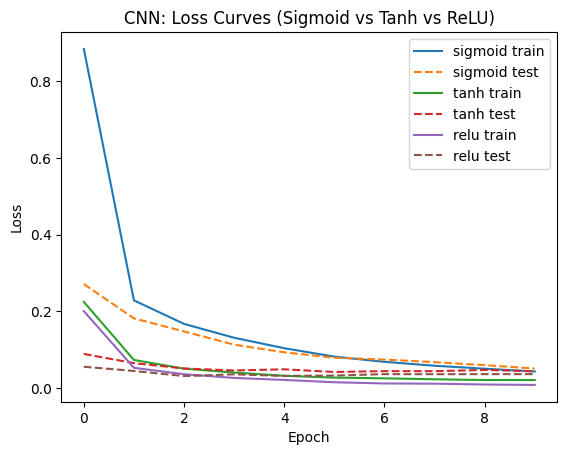

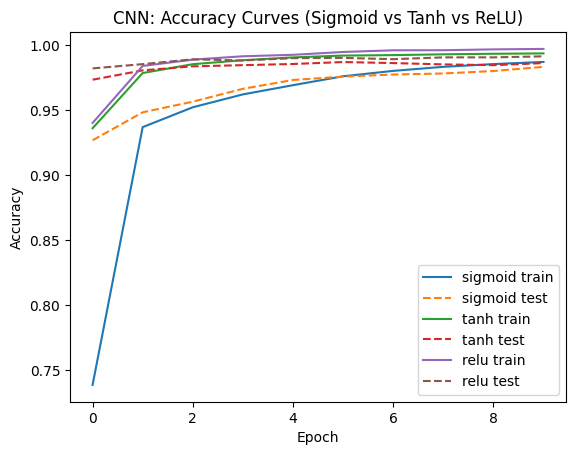

In [13]:
def plot_activation_curves(histories, title_prefix="CNN"):
    acts = list(histories.keys())

    # Loss curves
    plt.figure()
    for act in acts:
        h = histories[act]
        plt.plot(h["train_loss"], label=f"{act} train")
        plt.plot(h["test_loss"], linestyle="--", label=f"{act} test")
    plt.title(f"{title_prefix}: Loss Curves (Sigmoid vs Tanh vs ReLU)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # Accuracy curves
    plt.figure()
    for act in acts:
        h = histories[act]
        plt.plot(h["train_acc"], label=f"{act} train")
        plt.plot(h["test_acc"], linestyle="--", label=f"{act} test")
    plt.title(f"{title_prefix}: Accuracy Curves (Sigmoid vs Tanh vs ReLU)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_activation_curves(cnn_act_histories, title_prefix="CNN")


In [14]:
# 1) Final accuracy summary
print("===== FINAL TEST ACCURACY (CNN) =====")
for act, h in cnn_act_histories.items():
    print(f"{act.upper():7s} -> test_acc = {h['test_acc'][-1]*100:.2f}%")

# 2) Ready-to-paste observations template (you can edit after seeing your curves)
print("\n===== TASK 1 OBSERVATIONS (PASTE IN LAB FILE) =====\n")
print(
"""1) Sigmoid:
- Observed: Training accuracy increased slowly and loss decreased slowly (often flatter in early epochs).
- Reason: Sigmoid saturates near 0 or 1, causing very small gradients in backpropagation (vanishing gradients), so learning becomes slow.

2) Tanh:
- Observed: Converged faster than sigmoid (loss reduced more steadily and accuracy increased earlier).
- Reason: Tanh is zero-centered (-1 to +1), which helps optimization compared to sigmoid, but it can still saturate at extremes, so gradients can still shrink.

3) ReLU:
- Observed: Fastest convergence among the three (loss dropped quickly and accuracy rose fastest).
- Reason: ReLU does not saturate for positive values and keeps gradients stronger, which reduces vanishing-gradient issues and speeds up training.
"""
)


===== FINAL TEST ACCURACY (CNN) =====
SIGMOID -> test_acc = 98.34%
TANH    -> test_acc = 98.63%
RELU    -> test_acc = 99.15%

===== TASK 1 OBSERVATIONS (PASTE IN LAB FILE) =====

1) Sigmoid:
- Observed: Training accuracy increased slowly and loss decreased slowly (often flatter in early epochs).
- Reason: Sigmoid saturates near 0 or 1, causing very small gradients in backpropagation (vanishing gradients), so learning becomes slow.

2) Tanh:
- Observed: Converged faster than sigmoid (loss reduced more steadily and accuracy increased earlier).
- Reason: Tanh is zero-centered (-1 to +1), which helps optimization compared to sigmoid, but it can still saturate at extremes, so gradients can still shrink.

3) ReLU:
- Observed: Fastest convergence among the three (loss dropped quickly and accuracy rose fastest).
- Reason: ReLU does not saturate for positive values and keeps gradients stronger, which reduces vanishing-gradient issues and speeds up training.



#TASK 2

In [15]:
def run_optimizer_showdown_cnn(epochs=10):
    optimizers = {
        "SGD": optim.SGD,
        "SGD+Momentum": lambda params: optim.SGD(params, lr=0.1, momentum=0.9),
        "Adam": lambda params: optim.Adam(params, lr=1e-3),
    }

    opt_histories = {}

    for opt_name, opt_fn in optimizers.items():
        torch.manual_seed(42)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(42)

        model = CNNWithActivation(act_name="relu", fc_units=128).to(device)

        # Build optimizer
        if opt_name == "SGD":
            optimizer = optim.SGD(model.parameters(), lr=0.1)  # plain SGD
        else:
            optimizer = opt_fn(model.parameters())

        print("\n====================================")
        print(f"Training CNN (ReLU) with optimizer: {opt_name}")
        print("====================================")

        hist = run_training(model, optimizer, epochs=epochs)
        opt_histories[opt_name] = hist

    return opt_histories

cnn_opt_histories = run_optimizer_showdown_cnn(epochs=10)



Training CNN (ReLU) with optimizer: SGD
Epoch 01/10 | train_loss=0.4374 train_acc=0.8640 | test_loss=0.1443 test_acc=0.9571
Epoch 02/10 | train_loss=0.1299 train_acc=0.9597 | test_loss=0.0808 test_acc=0.9754
Epoch 03/10 | train_loss=0.0784 train_acc=0.9760 | test_loss=0.0550 test_acc=0.9826
Epoch 04/10 | train_loss=0.0562 train_acc=0.9825 | test_loss=0.0590 test_acc=0.9809
Epoch 05/10 | train_loss=0.0451 train_acc=0.9857 | test_loss=0.0454 test_acc=0.9850
Epoch 06/10 | train_loss=0.0359 train_acc=0.9887 | test_loss=0.0437 test_acc=0.9863
Epoch 07/10 | train_loss=0.0314 train_acc=0.9900 | test_loss=0.0386 test_acc=0.9870
Epoch 08/10 | train_loss=0.0264 train_acc=0.9916 | test_loss=0.0339 test_acc=0.9880
Epoch 09/10 | train_loss=0.0225 train_acc=0.9931 | test_loss=0.0394 test_acc=0.9874
Epoch 10/10 | train_loss=0.0182 train_acc=0.9947 | test_loss=0.0303 test_acc=0.9894

Training CNN (ReLU) with optimizer: SGD+Momentum
Epoch 01/10 | train_loss=0.4515 train_acc=0.8588 | test_loss=0.0911 t

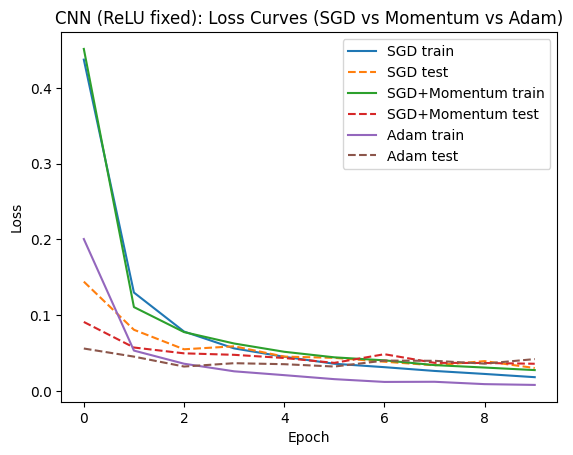

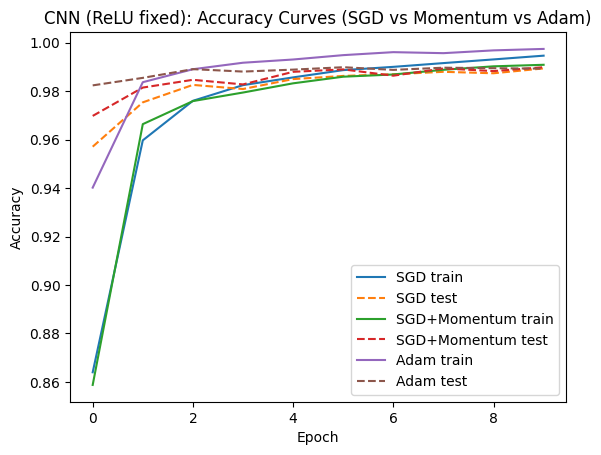

===== FINAL TEST ACCURACY (CNN, ReLU fixed) =====
SGD          -> test_acc = 98.94%
SGD+Momentum -> test_acc = 98.99%
Adam         -> test_acc = 98.93%


In [16]:
def plot_optimizer_curves(histories, title_prefix="CNN (ReLU fixed)"):
    opts = list(histories.keys())

    # Loss curves
    plt.figure()
    for opt_name in opts:
        h = histories[opt_name]
        plt.plot(h["train_loss"], label=f"{opt_name} train")
        plt.plot(h["test_loss"], linestyle="--", label=f"{opt_name} test")
    plt.title(f"{title_prefix}: Loss Curves (SGD vs Momentum vs Adam)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # Accuracy curves
    plt.figure()
    for opt_name in opts:
        h = histories[opt_name]
        plt.plot(h["train_acc"], label=f"{opt_name} train")
        plt.plot(h["test_acc"], linestyle="--", label=f"{opt_name} test")
    plt.title(f"{title_prefix}: Accuracy Curves (SGD vs Momentum vs Adam)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_optimizer_curves(cnn_opt_histories)

print("===== FINAL TEST ACCURACY (CNN, ReLU fixed) =====")
for opt_name, h in cnn_opt_histories.items():
    print(f"{opt_name:12s} -> test_acc = {h['test_acc'][-1]*100:.2f}%")


In [17]:
def get_final_acc(hist_dict):
    return hist_dict["test_acc"][-1] * 100

print("\n===== TASK 2 (OPTIMIZER SHOWDOWN) — CONCLUSION TEXT =====\n")

if "cnn_opt_histories" not in globals():
    print("Run Block 19 and 20 first to generate cnn_opt_histories.")
else:
    sgd_acc   = get_final_acc(cnn_opt_histories["SGD"])
    mom_acc   = get_final_acc(cnn_opt_histories["SGD+Momentum"])
    adam_acc  = get_final_acc(cnn_opt_histories["Adam"])

    print(f"Final Test Accuracies (CNN with ReLU fixed):")
    print(f"- SGD: {sgd_acc:.2f}%")
    print(f"- SGD with Momentum: {mom_acc:.2f}%")
    print(f"- Adam: {adam_acc:.2f}%\n")

    print("Conclusion (Task 2):")
    print(
        f"- Basic SGD showed comparatively slower convergence and more fluctuation in the loss curve, "
        f"because it uses a single learning rate and updates can oscillate.\n"
        f"- SGD with Momentum reduced oscillations and handled bumps in the loss landscape better by carrying "
        f"forward part of the previous update direction, which improved stability and typically reached higher accuracy than plain SGD.\n"
        f"- Adam reached high accuracy the fastest because it adaptively adjusts learning rates for different parameters, "
        f"leading to quicker loss reduction and faster convergence.\n\n"
        f"Measured results support this: SGD={sgd_acc:.2f}%, Momentum={mom_acc:.2f}%, Adam={adam_acc:.2f}%."
    )



===== TASK 2 (OPTIMIZER SHOWDOWN) — CONCLUSION TEXT =====

Final Test Accuracies (CNN with ReLU fixed):
- SGD: 98.94%
- SGD with Momentum: 98.99%
- Adam: 98.93%

Conclusion (Task 2):
- Basic SGD showed comparatively slower convergence and more fluctuation in the loss curve, because it uses a single learning rate and updates can oscillate.
- SGD with Momentum reduced oscillations and handled bumps in the loss landscape better by carrying forward part of the previous update direction, which improved stability and typically reached higher accuracy than plain SGD.
- Adam reached high accuracy the fastest because it adaptively adjusts learning rates for different parameters, leading to quicker loss reduction and faster convergence.

Measured results support this: SGD=98.94%, Momentum=98.99%, Adam=98.93%.


In [18]:
class CNN_BN_Dropout(nn.Module):
    """
    CNN with optional BatchNorm and configurable Dropout.
    Base: Conv(32)->Conv(64)->MaxPool->Dropout->FC(128)->Output(10)
    """
    def __init__(self, use_bn=False, dropout_p=0.25, fc_units=128):
        super().__init__()
        self.use_bn = use_bn

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.bn1   = nn.BatchNorm2d(32) if use_bn else nn.Identity()

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.bn2   = nn.BatchNorm2d(64) if use_bn else nn.Identity()

        self.pool = nn.MaxPool2d(2, 2)
        self.drop = nn.Dropout(dropout_p) if dropout_p > 0 else nn.Identity()

        self.fc1 = nn.Linear(64 * 12 * 12, fc_units)
        self.bn_fc1 = nn.BatchNorm1d(fc_units) if use_bn else nn.Identity()

        self.fc2 = nn.Linear(fc_units, 10)

        self.act = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.act(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.act(x)

        x = self.pool(x)
        x = self.drop(x)

        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        x = self.bn_fc1(x)
        x = self.act(x)

        x = self.fc2(x)  # logits
        return x


def run_task3_cnn_variants(epochs=10):
    scenarios = {
        "No BN, No Dropout": {"use_bn": False, "dropout_p": 0.0},
        "No BN, Dropout=0.1": {"use_bn": False, "dropout_p": 0.1},
        "With BN, Dropout=0.25": {"use_bn": True, "dropout_p": 0.25},
    }

    histories = {}

    for name, cfg in scenarios.items():
        torch.manual_seed(42)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(42)

        model = CNN_BN_Dropout(use_bn=cfg["use_bn"], dropout_p=cfg["dropout_p"], fc_units=128)
        optimizer = optim.Adam(model.parameters(), lr=1e-3)  # keep optimizer constant

        print("\n====================================")
        print(f"Scenario: {name}")
        print("====================================")

        histories[name] = run_training(model, optimizer, epochs=epochs)

    return histories

task3_histories = run_task3_cnn_variants(epochs=10)



Scenario: No BN, No Dropout
Epoch 01/10 | train_loss=0.2056 train_acc=0.9386 | test_loss=0.0621 test_acc=0.9795
Epoch 02/10 | train_loss=0.0488 train_acc=0.9855 | test_loss=0.0479 test_acc=0.9854
Epoch 03/10 | train_loss=0.0318 train_acc=0.9901 | test_loss=0.0346 test_acc=0.9880
Epoch 04/10 | train_loss=0.0227 train_acc=0.9929 | test_loss=0.0353 test_acc=0.9887
Epoch 05/10 | train_loss=0.0173 train_acc=0.9944 | test_loss=0.0386 test_acc=0.9875
Epoch 06/10 | train_loss=0.0120 train_acc=0.9963 | test_loss=0.0395 test_acc=0.9886
Epoch 07/10 | train_loss=0.0100 train_acc=0.9968 | test_loss=0.0318 test_acc=0.9901
Epoch 08/10 | train_loss=0.0074 train_acc=0.9976 | test_loss=0.0429 test_acc=0.9889
Epoch 09/10 | train_loss=0.0067 train_acc=0.9977 | test_loss=0.0380 test_acc=0.9899
Epoch 10/10 | train_loss=0.0064 train_acc=0.9979 | test_loss=0.0393 test_acc=0.9895

Scenario: No BN, Dropout=0.1
Epoch 01/10 | train_loss=0.2044 train_acc=0.9392 | test_loss=0.0586 test_acc=0.9814
Epoch 02/10 | tra

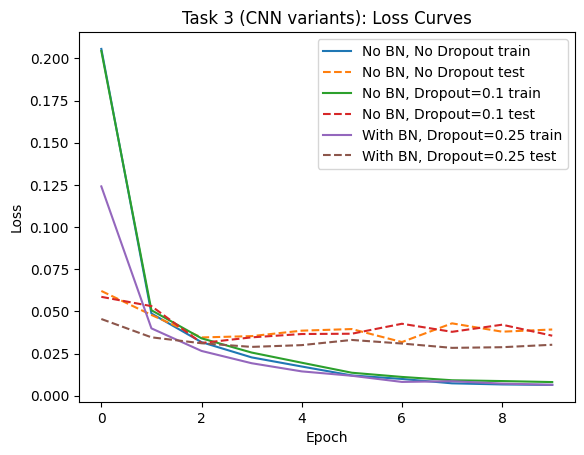

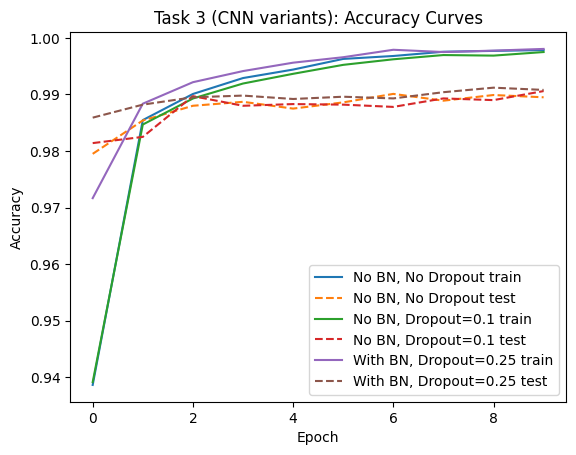

===== FINAL TEST ACCURACY (Task 3) =====
No BN, No Dropout      -> test_acc = 98.95%
No BN, Dropout=0.1     -> test_acc = 99.06%
With BN, Dropout=0.25  -> test_acc = 99.08%


In [19]:
def plot_task3(histories, title_prefix="Task 3 (CNN variants)"):
    names = list(histories.keys())

    # Loss
    plt.figure()
    for name in names:
        h = histories[name]
        plt.plot(h["train_loss"], label=f"{name} train")
        plt.plot(h["test_loss"], linestyle="--", label=f"{name} test")
    plt.title(f"{title_prefix}: Loss Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # Accuracy
    plt.figure()
    for name in names:
        h = histories[name]
        plt.plot(h["train_acc"], label=f"{name} train")
        plt.plot(h["test_acc"], linestyle="--", label=f"{name} test")
    plt.title(f"{title_prefix}: Accuracy Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_task3(task3_histories)

print("===== FINAL TEST ACCURACY (Task 3) =====")
for name, h in task3_histories.items():
    print(f"{name:22s} -> test_acc = {h['test_acc'][-1]*100:.2f}%")


In [20]:
print("\n===== TASK 3 (BN / DROPOUT) — CONCLUSION TEXT =====\n")

if "task3_histories" not in globals():
    print("Run Blocks 22 and 23 first to generate task3_histories.")
else:
    acc_no_bn_no_do = task3_histories["No BN, No Dropout"]["test_acc"][-1] * 100
    acc_no_bn_do01  = task3_histories["No BN, Dropout=0.1"]["test_acc"][-1] * 100
    acc_bn_do025    = task3_histories["With BN, Dropout=0.25"]["test_acc"][-1] * 100

    print("Final Test Accuracies (Task 3):")
    print(f"- Without BN & Without Dropout: {acc_no_bn_no_do:.2f}%")
    print(f"- Without BN, Dropout=0.1:      {acc_no_bn_do01:.2f}%")
    print(f"- With BN, Dropout=0.25:        {acc_bn_do025:.2f}%\n")

    print(
        "Conclusion (Task 3):\n"
        "- Without Batch Normalization and Dropout, the model usually fits the training data very quickly and can show a larger train–test gap (overfitting).\n"
        "- Adding Dropout=0.1 provides mild regularization, typically reducing overfitting and making test performance more stable.\n"
        "- Using Batch Normalization with a stronger Dropout=0.25 generally stabilizes training (smoother loss) and improves generalization by reducing internal covariate shift and limiting co-adaptation.\n\n"
        f"Measured results: NoBN+NoDO={acc_no_bn_no_do:.2f}%, NoBN+DO0.1={acc_no_bn_do01:.2f}%, BN+DO0.25={acc_bn_do025:.2f}%."
    )



===== TASK 3 (BN / DROPOUT) — CONCLUSION TEXT =====

Final Test Accuracies (Task 3):
- Without BN & Without Dropout: 98.95%
- Without BN, Dropout=0.1:      99.06%
- With BN, Dropout=0.25:        99.08%

Conclusion (Task 3):
- Without Batch Normalization and Dropout, the model usually fits the training data very quickly and can show a larger train–test gap (overfitting).
- Adding Dropout=0.1 provides mild regularization, typically reducing overfitting and making test performance more stable.
- Using Batch Normalization with a stronger Dropout=0.25 generally stabilizes training (smoother loss) and improves generalization by reducing internal covariate shift and limiting co-adaptation.

Measured results: NoBN+NoDO=98.95%, NoBN+DO0.1=99.06%, BN+DO0.25=99.08%.
